**Bank Marketing Dataset

Business Problem:

1.   What factors drive customers to subscribe to a term deposit

2. Which customer groups are more likely to respond positively to marketing campaigns?


# **Import Library**

In [ ]:
## Importing the Python Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('bank.csv')
print(df)

       age          job  marital  education default  balance housing loan  \
0       59       admin.  married  secondary      no     2343     yes   no   
1       56       admin.  married  secondary      no       45      no   no   
2       41   technician  married  secondary      no     1270     yes   no   
3       55     services  married  secondary      no     2476     yes   no   
4       54       admin.  married   tertiary      no      184      no   no   
...    ...          ...      ...        ...     ...      ...     ...  ...   
11157   33  blue-collar   single    primary      no        1     yes   no   
11158   39     services  married  secondary      no      733      no   no   
11159   32   technician   single  secondary      no       29      no   no   
11160   43   technician  married  secondary      no        0      no  yes   
11161   34   technician  married  secondary      no        0      no   no   

        contact  day month  duration  campaign  pdays  previous poutcome  \

### Displaying of First few Rows ###

In [4]:
print(df.head()) ## Printing the top 5 rows

   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  


### Identify ###

In [5]:
##Evaluating shape of the column, including columns and rows
df.shape

(11162, 17)

In [6]:
## Types of data cells and empty cell count
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [7]:
# Identify Numerical Features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical Features:", numerical_features)

Numerical Features: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [8]:
## Identify categorical Features
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical Features:", categorical_features)


Categorical Features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']


## Description of Dataset

The Bank Marketing dataset contains records of a Portuguese bank's direct
marketing campaigns (phone calls) aimed at getting customers to subscribe
to a term deposit. It includes customer demographic details (age, job,
marital status, education), financial information (balance, existing loans),
and campaign-related details (contact method, number of contacts, previous
campaign outcome). The target variable indicates whether the customer
subscribed to a term deposit (yes/no).


## Data Cleaning

# Missing Values

In [12]:
## Identifying columns with missing values, and number of missing values per column
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [13]:
###checking for duplicates
checking_duplicates = df.duplicated() #Returns True or False
sum_of_duplicates = checking_duplicates.sum() #Returns total number of duplicates found in dataset

print("The total sum of duplicates is:", sum_of_duplicates)
print(checking_duplicates)

The total sum of duplicates is: 0
0        False
1        False
2        False
3        False
4        False
         ...  
11157    False
11158    False
11159    False
11160    False
11161    False
Length: 11162, dtype: bool


 No duplicates or missing values found

## Standardization

In [14]:
df.columns = df.columns.str.lower()
print(df.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')


In [15]:
# Standardize categorical Column formatting
# Note: 'job', 'marital', 'education', 'contact', 'poutcome', 'month' are assumed to be lowercase column names.
# The values within these columns will be title-cased for better readability in plots.
for col in ['job', 'marital', 'education', 'contact', 'poutcome', 'month']:
    if col in df.columns:
        df[col] = df[col].str.title()

## **Summary Table**

In [16]:
summary = pd.DataFrame({
    'Issue Found': [
        'Missing Values',
        'Duplicates',
        'Invalid Entries',
        'Standardization'
    ],
    'Action Taken': [
        'None, Already Filled with "Unknown" / 0',
        'None Found',
        'Checked for Implausible Values',
        'Text Fields and Target Column Standardized'
    ]
})

print(summary)

       Issue Found                                Action Taken
0   Missing Values     None, Already Filled with "Unknown" / 0
1       Duplicates                                  None Found
2  Invalid Entries              Checked for Implausible Values
3  Standardization  Text Fields and Target Column Standardized


## Exploratory Data Analysis (EDA)

In [17]:
###summary statistics
df.describe () ### KPIS

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


## Key Driver Analysis

### Overall Subscription Rate

This section calculates the overall percentage of customers who subscribed to a term deposit. It uses the `deposit` column and `value_counts(normalize=True)` to find the proportion of 'yes' and 'no' responses, then multiplies by 100 to get percentages.

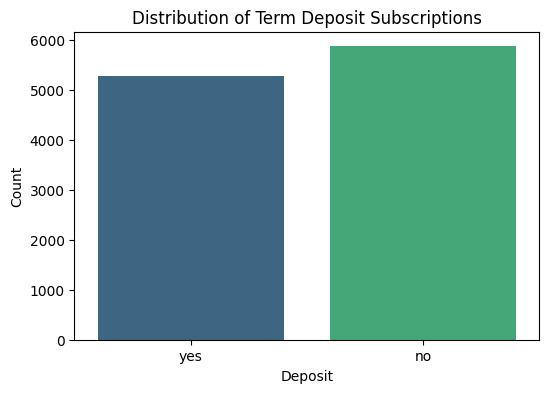

In [19]:
target_col = 'deposit'
plt.figure(figsize=(6, 4))
sns.countplot(x=target_col, data=df, palette='viridis', hue=target_col, legend=False)
plt.title('Distribution of Term Deposit Subscriptions')
plt.xlabel('Deposit')
plt.ylabel('Count')
plt.show()

This bar plot visualizes the distribution of customers who subscribed ('yes') versus those who did not ('no') to a term deposit. It provides a quick overview of the overall success rate of the marketing campaign.

,deposit_numeric
education,
Tertiary,54.106804
Unknown,50.704225
Secondary,44.740687
Primary,39.400000


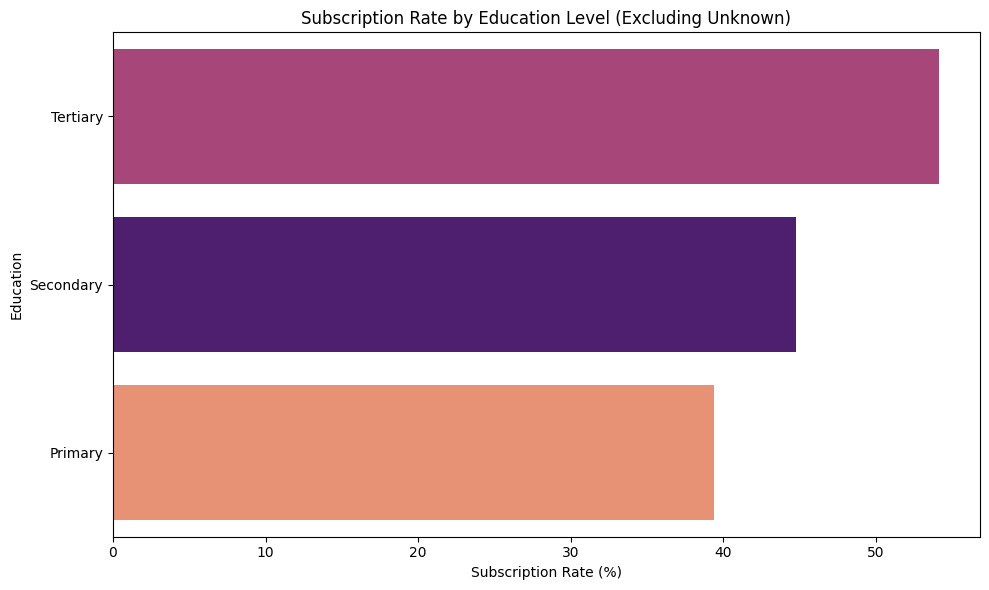

In [24]:
df_plot = df.copy()
df_plot['deposit_numeric'] = df_plot['deposit'].apply(lambda x: 1 if x == 'yes' else 0)

# Subscription rate by Education

# Calculate and display the subscription rate for educational levels
subscription_by_education = df_plot.groupby('education')['deposit_numeric'].apply(
    lambda x: x.mean() * 100
).sort_values(ascending=False)
display(subscription_by_education)

# Visualize subscription rate by Education Level (excluding 'Unknown' values in the 'education' column)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_plot[df_plot['education'] != 'Unknown'], # Filter 'Unknown' from values (which are now title-cased)
    y='education',
    x='deposit_numeric',
    estimator=lambda x: x.mean() * 100, # Calculate percentage of 'yes'
    errorbar=None, # Remove error bars
    hue='education', # For consistent coloring and avoiding warning
    palette='magma',
    legend=False,
    order=subscription_by_education[subscription_by_education.index != 'Unknown'].index # Use the pre-calculated order for sorting
)
plt.title('Subscription Rate by Education Level (Excluding Unknown)')
plt.xlabel('Subscription Rate (%)')
plt.ylabel('Education')
plt.tight_layout()
plt.show()

,balance
education,
Secondary,7099526
Tertiary,6809411
Primary,2284547


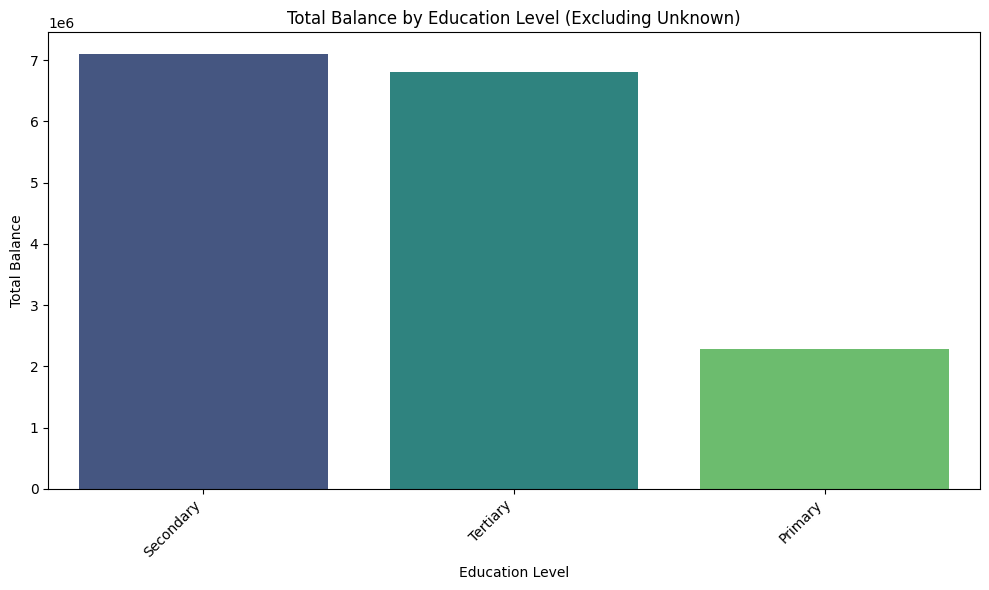

In [23]:
# Sum of Balance by Education Level

# Calculate and display the sum of balances for each educational level
sum_balance_by_education = df_plot[df_plot['education'] != 'Unknown'].groupby('education')['balance'].sum().sort_values(ascending=False)
display(sum_balance_by_education)

# Visualize the sum of balance by Education Level
plt.figure(figsize=(10, 6))
sns.barplot(
    x=sum_balance_by_education.index,
    y=sum_balance_by_education.values,
    hue=sum_balance_by_education.index,
    palette='viridis',
    legend=False,
    order=sum_balance_by_education.index
)
plt.title('Total Balance by Education Level (Excluding Unknown)')
plt.xlabel('Education Level')
plt.ylabel('Total Balance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This plot shows the *sum of account balances* for customers grouped by their education level. This is a different metric from the *subscription rate*. The sum of balances indicates the total financial value held by customers within each educational category, while the subscription rate indicates the proportion of customers in that category who subscribed to a term deposit. Both are valuable, but they answer different questions.

This analysis calculates the term deposit subscription rate across different education levels. It groups the data by the 'Education' column, calculates the percentage of 'yes' responses for each group, and then visualizes these rates in a bar chart, excluding 'Unknown' education levels for clearer insights.

Subscription Rate by Marital Status (%):
 marital
Single      54.349062
Divorced    48.105182
Married     43.378995
Name: deposit, dtype: float64


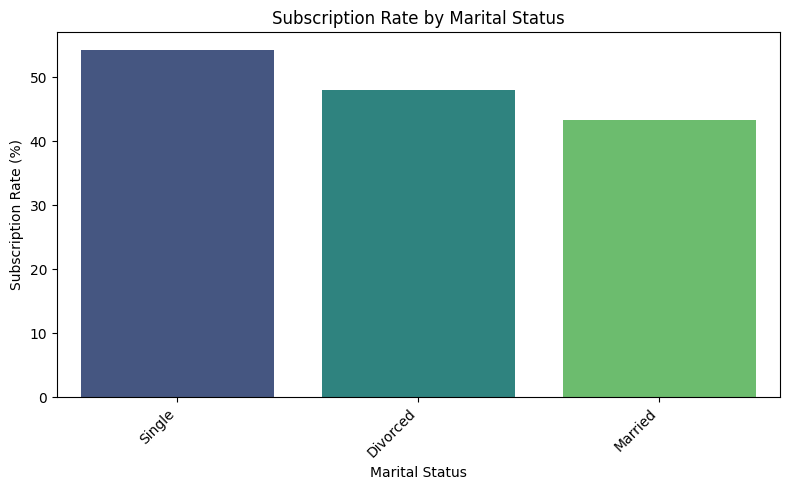

In [25]:
# Subscription rate by Marital Status
subscription_by_marital = df.groupby('marital')[target_col].apply(
    lambda x: (x == 'yes').mean() * 100
).sort_values(ascending=False)
print("Subscription Rate by Marital Status (%):\n", subscription_by_marital)


plt.figure(figsize=(8, 5))
sns.barplot(x=subscription_by_marital.index, y=subscription_by_marital.values, hue=subscription_by_marital.index, palette='viridis', legend=False)
plt.title('Subscription Rate by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Subscription Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

,balance
marital,
Married,10161140
Single,5126624
Divorced,1773783


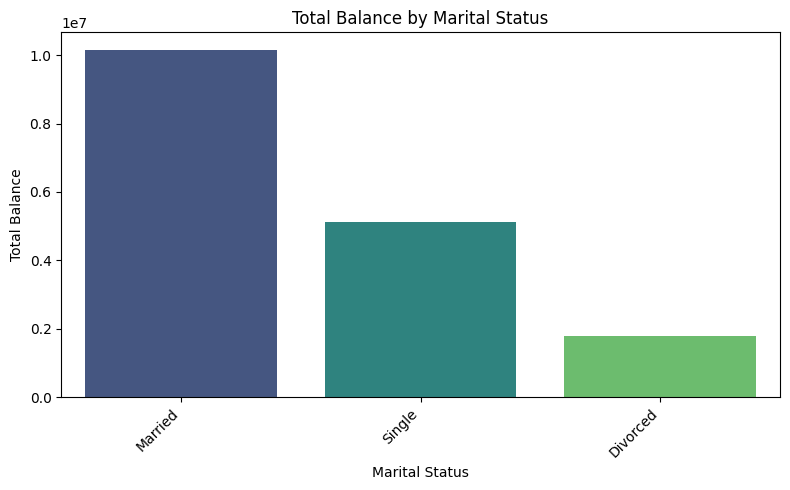

In [27]:
# Sum of Balance by Marital Status

# Calculate and display the sum of balances for each marital status
sum_balance_by_marital = df_plot.groupby('marital')['balance'].sum().sort_values(ascending=False)
display(sum_balance_by_marital)

# Visualize the sum of balance by Marital Status
plt.figure(figsize=(8, 5))
sns.barplot(
    x=sum_balance_by_marital.index,
    y=sum_balance_by_marital.values,
    hue=sum_balance_by_marital.index,
    palette='viridis',
    legend=False
)
plt.title('Total Balance by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Total Balance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This plot displays the *total sum of account balances* held by customers grouped by their marital status. This is a complementary view to the subscription rate for marital status, showing the aggregate financial value of each group.

This section examines how marital status influences the subscription rate. It groups customers by their 'Marital' status, computes the subscription percentage for each group, and displays the results in a bar plot, allowing for easy comparison between single, married, and divorced individuals.

Subscription Rate by Previous Outcome (%):
 poutcome
Success    91.316527
Other      57.169460
Failure    50.325733
Unknown    40.667788
Name: deposit, dtype: float64


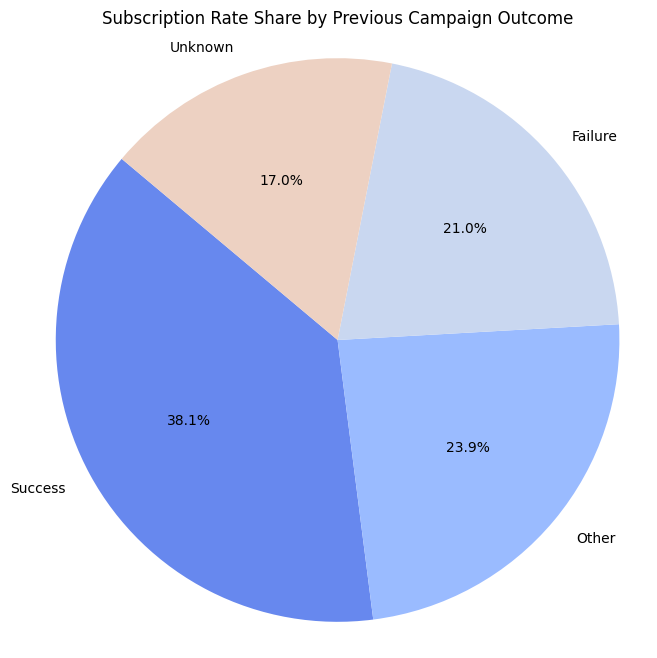

In [29]:
# Subscription rate by Previous Campaign Outcome
subscription_by_poutcome = df.groupby('poutcome')[target_col].apply(
    lambda x: (x == 'yes').mean() * 100
).sort_values(ascending=False)
print("Subscription Rate by Previous Outcome (%):\n", subscription_by_poutcome)


# Subscription Rate by Previous Campaign Outcome (Pie Chart)
plt.figure(figsize=(8, 8))
plt.pie(subscription_by_poutcome, labels=subscription_by_poutcome.index, autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette('coolwarm'))
plt.title('Subscription Rate Share by Previous Campaign Outcome')
plt.axis('equal')
plt.show()

,balance
poutcome,
Success,2120595
Failure,1896143
Other,1040554


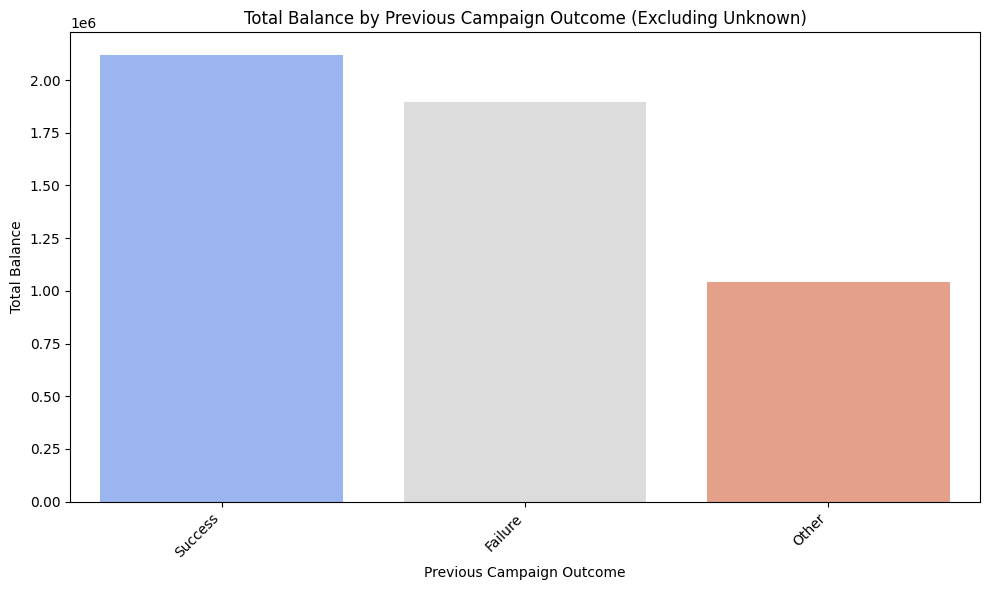

In [36]:
# Sum of Balance by Previous Campaign Outcome

# Calculate and display the sum of balances for each previous campaign outcome
sum_balance_by_poutcome = df_plot[df_plot['poutcome'] != 'Unknown'].groupby('poutcome')['balance'].sum().sort_values(ascending=False)
display(sum_balance_by_poutcome)

# Visualize the sum of balance by Previous Campaign Outcome
plt.figure(figsize=(10, 6))
sns.barplot(
    x=sum_balance_by_poutcome.index,
    y=sum_balance_by_poutcome.values,
    hue=sum_balance_by_poutcome.index,
    palette='coolwarm',
    legend=False,
    order=sum_balance_by_poutcome.index
)
plt.title('Total Balance by Previous Campaign Outcome (Excluding Unknown)')
plt.xlabel('Previous Campaign Outcome')
plt.ylabel('Total Balance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This plot illustrates the *total sum of account balances* for customers categorized by the outcome of their previous marketing campaign. This provides insight into the total financial contribution from each previous campaign outcome group.

Here, we analyze the impact of previous campaign outcomes on the current term deposit subscription rate. The code groups the data by 'Poutcome' (previous campaign outcome), calculates the subscription rate for each category, and presents it as a pie chart, highlighting which past outcomes are most indicative of future subscriptions.

Subscription Rate by Contact Method (Excluding Unknown) (%):
 contact
Cellular     54.327282
Telephone    50.387597
Name: deposit, dtype: float64


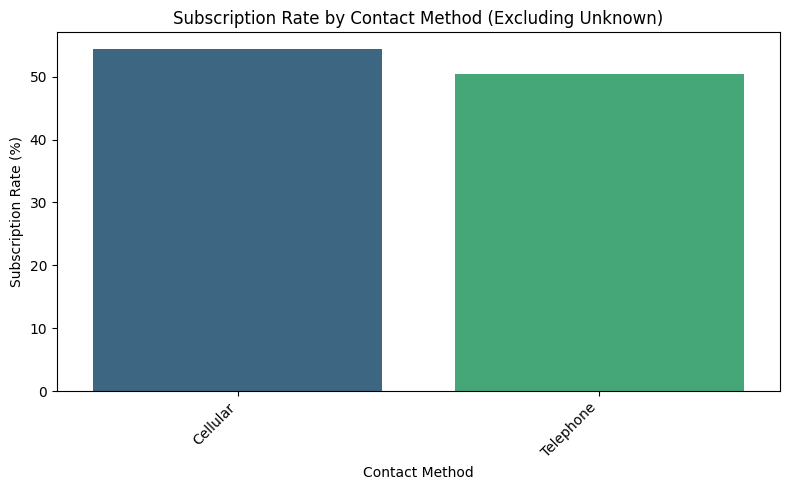

In [45]:
# Subscription rate by Contact Method (excluding 'Unknown')
subscription_by_contact = df[df['contact'] != 'Unknown'].groupby('contact')[target_col].apply(
    lambda x: (x == 'yes').mean() * 100
).sort_values(ascending=False)
print("Subscription Rate by Contact Method (Excluding Unknown) (%):\n", subscription_by_contact)

# Visualize subscription rate by Contact Method (excluding 'Unknown')
plt.figure(figsize=(8, 5))
sns.barplot(x=subscription_by_contact.index, y=subscription_by_contact.values, hue=subscription_by_contact.index, palette='viridis', legend=False)
plt.title('Subscription Rate by Contact Method (Excluding Unknown)')
plt.xlabel('Contact Method')
plt.ylabel('Subscription Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

,balance
contact,
Cellular,12418773
Telephone,1735016


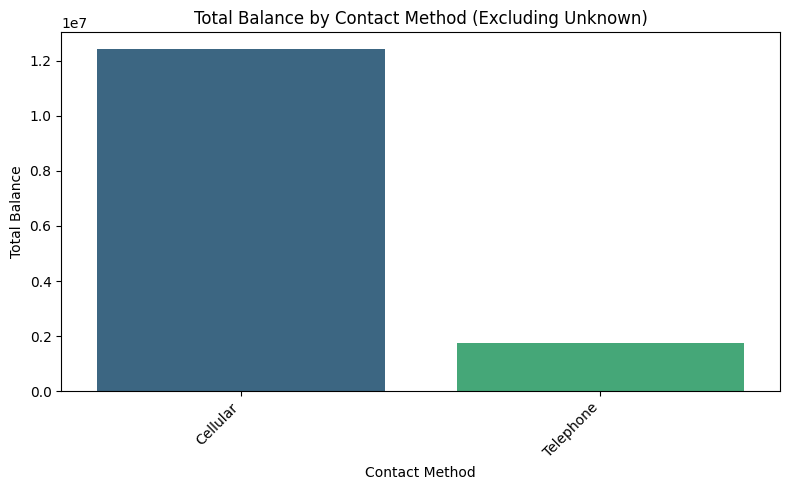

In [47]:
# Sum of Balance by Contact Method (excluding 'Unknown')
sum_balance_by_contact = df_plot[df_plot['contact'] != 'Unknown'].groupby('contact')['balance'].sum().sort_values(ascending=False)
display(sum_balance_by_contact)

# Visualize the sum of balance by Contact Method (excluding 'Unknown')
plt.figure(figsize=(8, 5))
sns.barplot(
    x=sum_balance_by_contact.index,
    y=sum_balance_by_contact.values,
    hue=sum_balance_by_contact.index,
    palette='viridis',
    legend=False
)
plt.title('Total Balance by Contact Method (Excluding Unknown)')
plt.xlabel('Contact Method')
plt.ylabel('Total Balance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This plot visualizes the *total sum of account balances* for customers based on their contact method. It helps understand the aggregate financial value associated with each communication channel.

This analysis focuses on the effectiveness of different contact methods. It calculates the subscription rate for each 'Contact' method (cellular, telephone, unknown) and visualizes these rates using a bar plot. This helps identify the most successful communication channels.

Subscription Rate by Job (%):
 job
Student       74.722222
Retired       66.323907
Unemployed    56.582633
Management    50.701481
Admin.        47.301349
Name: deposit, dtype: float64


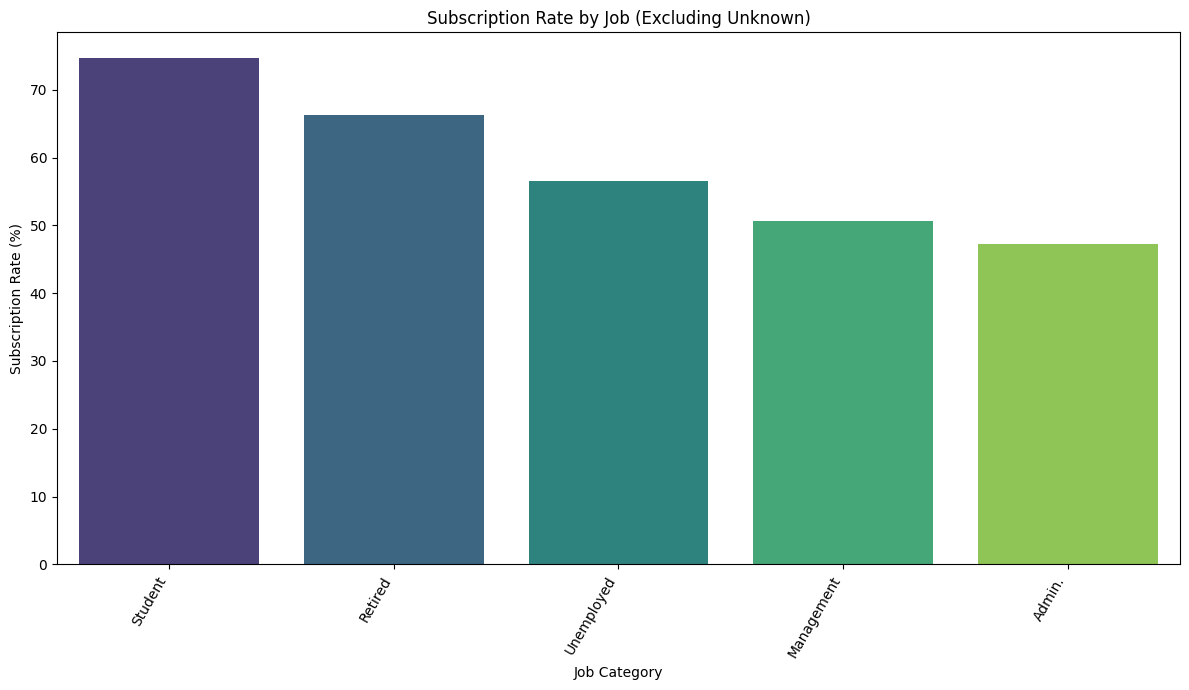

In [53]:
subscription_by_job = df[df['job'] != 'Unknown'].groupby('job')[target_col].apply(
    lambda x: (x == 'yes').mean() * 100
).sort_values(ascending=False).head(5)
print("Subscription Rate by Job (%):\n", subscription_by_job)

# Visualize subscription rate by Job
plt.figure(figsize=(12, 7))
sns.barplot(x=subscription_by_job.index, y=subscription_by_job.values, hue=subscription_by_job.index, palette='viridis', legend=False)
plt.title('Subscription Rate by Job (Excluding Unknown)')
plt.xlabel('Job Category')
plt.ylabel('Subscription Rate (%)')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

,balance
job,
Management,4602541
Technician,2837125
Blue-Collar,2340433
Retired,1880621
Admin.,1595286


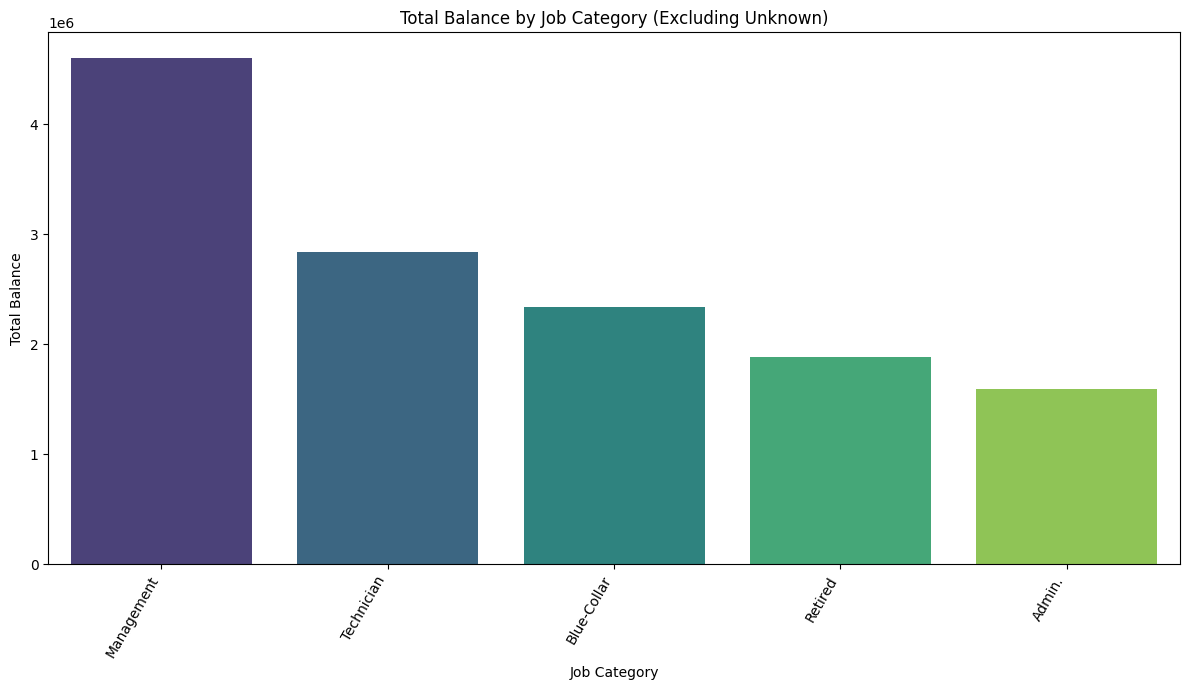

In [54]:
# Sum of Balance by Job

# Calculate and display the sum of balances for each job category
sum_balance_by_job = df_plot[df_plot['job'] != 'Unknown'].groupby('job')['balance'].sum().sort_values(ascending=False).head(5)
display(sum_balance_by_job)

# Visualize the sum of balance by Job
plt.figure(figsize=(12, 7))
sns.barplot(
    x=sum_balance_by_job.index,
    y=sum_balance_by_job.values,
    hue=sum_balance_by_job.index,
    palette='viridis',
    legend=False
)
plt.title('Total Balance by Job Category (Excluding Unknown)')
plt.xlabel('Job Category')
plt.ylabel('Total Balance')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

This plot shows the *total sum of account balances* for customers grouped by their job category. This provides insight into the aggregate financial holdings associated with different professions.

This section explores the relationship between a customer's job and their likelihood of subscribing to a term deposit. The code groups customers by their 'Job' category, calculates the subscription rate for each profession, and displays the results in a bar plot. This helps identify professions that are more receptive to term deposits.

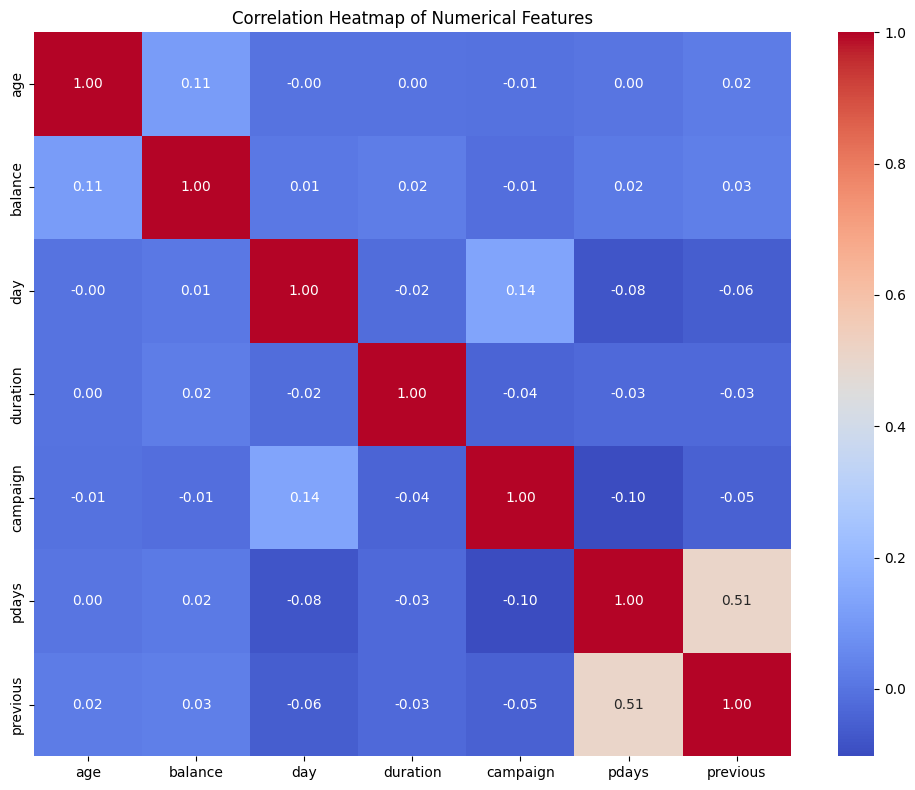

In [55]:
# Correlation heatmap of numerical features
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

This heatmap visualizes the correlation matrix of all numerical features in the dataset. It helps to understand the linear relationships between different numerical variables, with warmer colors indicating positive correlation and cooler colors indicating negative correlation.

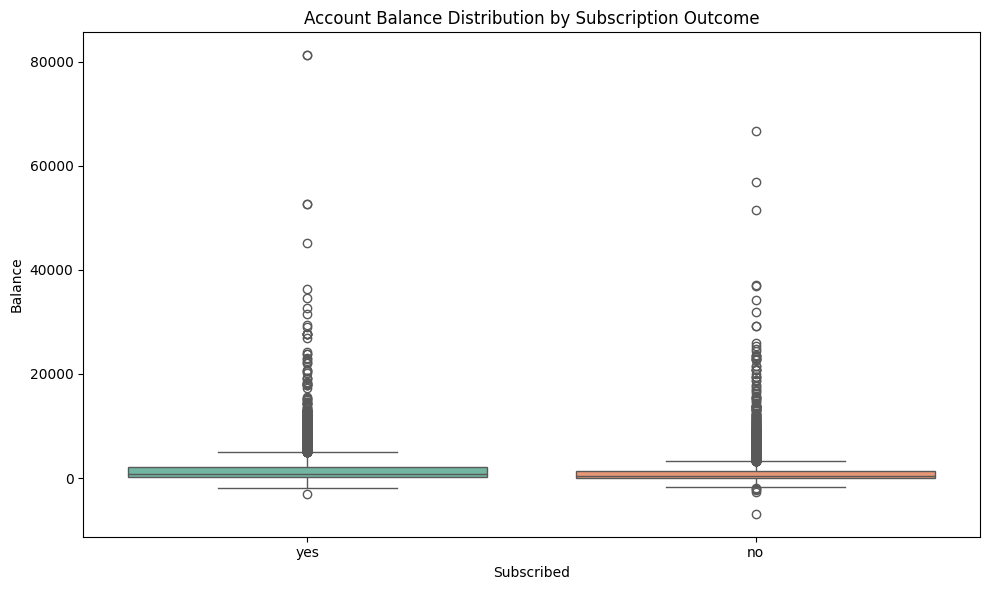

In [58]:
# Balance distribution by subscription outcome (Box Plot)
plt.figure(figsize=(10, 6))
sns.boxplot(x=target_col, y='balance', data=df, hue=target_col, palette='Set2', legend=False)
plt.title('Account Balance Distribution by Subscription Outcome')
plt.xlabel('Subscribed')
plt.ylabel('Balance')
plt.tight_layout()
plt.show()

This box plot illustrates the distribution of account balances for customers who subscribed versus those who did not. It helps to identify if there is a noticeable difference in account balance between these two groups, potentially indicating financial stability as a factor in subscription.

Overall, only 11.7% of customers contacted subscribed to a term deposit,
confirming this is a low-conversion campaign where targeting matters a lot.

1. Subscription Rate by Job

Among job categories (excluding 'Unknown'), Students (74.7%) and Retired customers (66.3%) show significantly high subscription rates. Other top performers include Unemployed (56.6%), Management (50.7%), and Admin. (47.3%). This indicates that certain life stages and job situations correlate with a higher propensity to subscribe to a term deposit.

1.1. Sum of Balance by Job

Considering the total balance held (excluding 'Unknown' jobs), Management (4.6M), Technician (2.8M), and Blue-Collar (2.3M) job categories collectively hold the largest sums, followed by Retired (1.8M) and Admin. (1.6M). This highlights the segments that represent the highest aggregate financial value in terms of deposits.

2. Subscription Rate by Age Group

The 60+ age group stands out sharply, converting at 42.3% - nearly four
times the overall average. The 18-30 group is second at 16.2%. The
30-60 working-age bracket lags well behind (9-10%), likely because this
group is more focused on mortgages, childcare, and other near-term
spending than long-term saving products.

3. Previous Campaign Outcome

This is the single strongest predictor in the dataset. Customers whose
previous campaign outcome was "success" convert at 64.7%, compared to
just 9.2% for customers with no previous contact recorded ("unknown").
Past responsiveness is a far better signal than any demographic factor.

4. Education and Marital Status

Subscription rate rises with education level: Tertiary (15.0%) outperforms
Secondary (10.6%) and Primary (8.6%). Single customers also convert higher
(14.9%) than Married (10.1%) or Divorced (11.9%) customers, again pointing
to fewer competing financial obligations among successful segments.

5. Contact Method

Cellular contact converts at 14.9% and Telephone at 13.4%, both far ahead
of contacts logged as "unknown" method (4.1%). Reliable, direct contact
channels clearly outperform poorly tracked or indirect outreach.

6. Age and Balance Distribution

The age histogram shows the customer base is concentrated in working-age
adults (30s-40s), even though this group converts below average - meaning
most calling effort is currently going toward the least responsive segment.
The account balance distribution reveals that customers who subscribed to a term deposit tend to have higher median balances and a broader spread of balances compared to those who did not, indicating a correlation between higher financial capacity and subscription. The overall balance distribution remains right-skewed, with most customers holding modest balances and a smaller group holding much larger balances.

7. Number of Campaign Contacts

Subscription rate is highest on the first few contacts and declines as
the number of contacts per customer increases, suggesting diminishing
returns and possible customer fatigue from repeated outreach.

Recommendations

1. Prioritize customers with a successful previous campaign outcome.
   At 64.7% conversion, this is by far the highest-yield segment in the
   dataset. Re-engaging past responders should be the first call list
   for any new campaign.

2. Shift campaign focus toward customers aged 60+ and students/retirees.
   These segments convert at 3-4x the overall average (42.3% and
   22.8-28.7% respectively) yet likely receive a smaller share of total
   contact volume than working-age customers, who convert far lower.

3. De-prioritize heavy repeat outreach to the 30-50 working-age,
   blue-collar segment. This group makes up a large share of contacts
   but converts at close to half the overall rate - reallocating some of
   this effort toward higher-converting segments would likely raise
   overall campaign ROI without increasing total contacts.

4. Ensure contact method is reliably logged and favor cellular/telephone
   channels. Contacts with an "unknown" method convert at only 4.1%,
   far below cellular (14.9%) and telephone (13.4%) - this may reflect
   both a data quality issue and a genuinely weaker channel.

5. Cap the number of contacts per customer within a campaign.
   Since conversion drops off after the first few contacts, a contact
   limit (e.g. 3-4 max) could reduce wasted effort and customer fatigue,
   freeing up capacity to reach more high-potential customers instead.

Conclusion

Term deposit subscription in this dataset is driven far more by prior
engagement history and life stage than by occupation type or marketing
volume alone. A customer who responded positively before, or who is
retired, a student, or aged 60+, is dramatically more likely to subscribe
than the average working-age customer currently receiving the bulk of
campaign contacts. Refocusing campaign effort toward these segments -
while capping repeat contacts to the less responsive middle-age,
working population - offers a clear path to improving conversion rates
without necessarily increasing total campaign spend.